
# Machine Learning (tIIAD1008-01)- Examen Aplicado

Carrera: Ingeniería en Inteligencia Artificial

Profesor: Danilo Gomez

Fecha de Envío: 07.09.2026

Nombre de Estudiante: Ana Díaz



## Dataset: Online Shoppers Purchasing Intention

- **Fuente:** UCI Machine Learning Repository
- **URL:** https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset
- **Número de observaciones:** 12.330
- **Número de variables predictoras:** (17 variables predictoras y 1 variable objetivo)
- **Variable objetivo:** Revenue
- **Tipo de tarea:** Clasificación binaria

### Descripción

El dataset Online Shoppers Purchasing Intention contiene información correspondiente a sesiones de navegación de usuarios en un sitio de comercio electrónico. Las variables describen características del comportamiento de navegación y otros aspectos asociados a cada sesión.

El objetivo del análisis es predecir si una sesión finalizará en una compra, utilizando como variable objetivo `Revenue`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

ruta = '/content/drive/MyDrive/online_shoppers_intention.csv'
df = pd.read_csv(ruta)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# Dimensiones del dataset
df.shape

(12330, 18)

In [5]:
# Tipos de datos de cada variable
df.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [6]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [8]:
# Porcentaje de valores faltantes por columna
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
porcentaje_nulos

,0
Administrative,0.0
Administrative_Duration,0.0
Informational,0.0
Informational_Duration,0.0
ProductRelated,0.0
ProductRelated_Duration,0.0
BounceRates,0.0
ExitRates,0.0
PageValues,0.0
SpecialDay,0.0


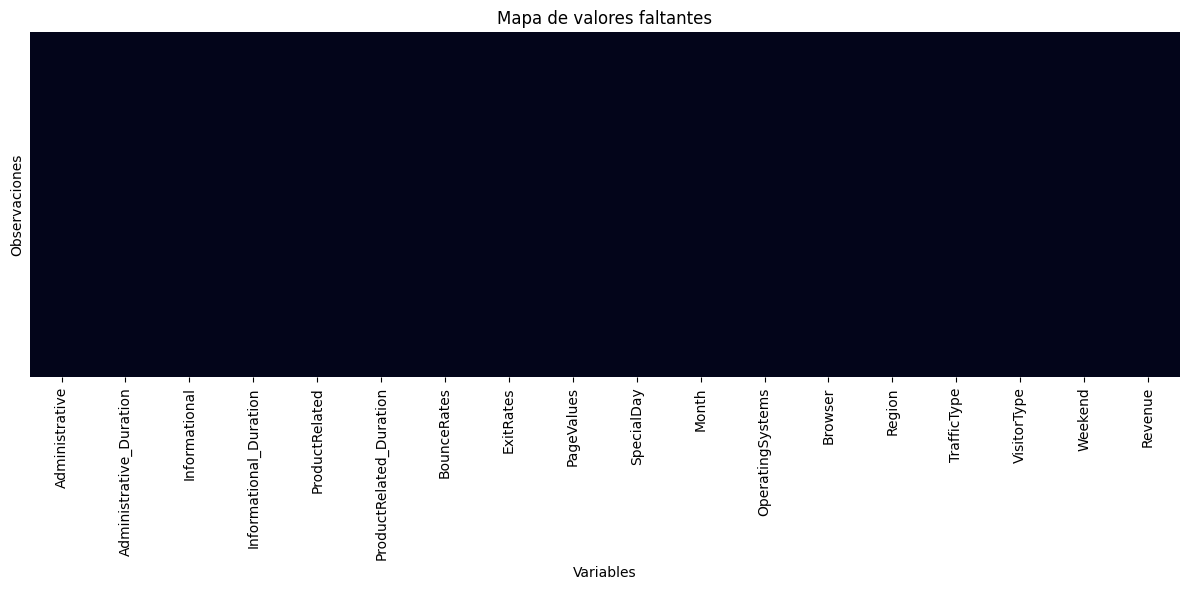

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Mapa de valores faltantes')
plt.xlabel('Variables')
plt.ylabel('Observaciones')

plt.tight_layout()
plt.savefig(
    'figures/01_mapa_valores_faltantes.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Análisis de valores faltantes

El análisis de valores faltantes muestra que todas las variables presentan un 0% de datos nulos. El mapa de calor confirma este resultado, ya que no se observan valores faltantes en ninguna de las columnas del dataset.

Por lo tanto, no es necesario eliminar variables ni aplicar métodos de imputación en esta etapa. Sin embargo, posteriormente se incorporará un método de imputación dentro del pipeline de preprocesamiento para mantener un procedimiento robusto y reproducible.

In [10]:
# Variables numéricas clave para el análisis de outliers
variables_numericas = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

In [11]:
# Detección de outliers mediante el método IQR
for columna in variables_numericas:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(f"{columna}: {len(outliers)} outliers")

Administrative: 404 outliers
Administrative_Duration: 1172 outliers
Informational: 2631 outliers
Informational_Duration: 2405 outliers
ProductRelated: 987 outliers
ProductRelated_Duration: 961 outliers
BounceRates: 1551 outliers
ExitRates: 1099 outliers
PageValues: 2730 outliers
SpecialDay: 1251 outliers


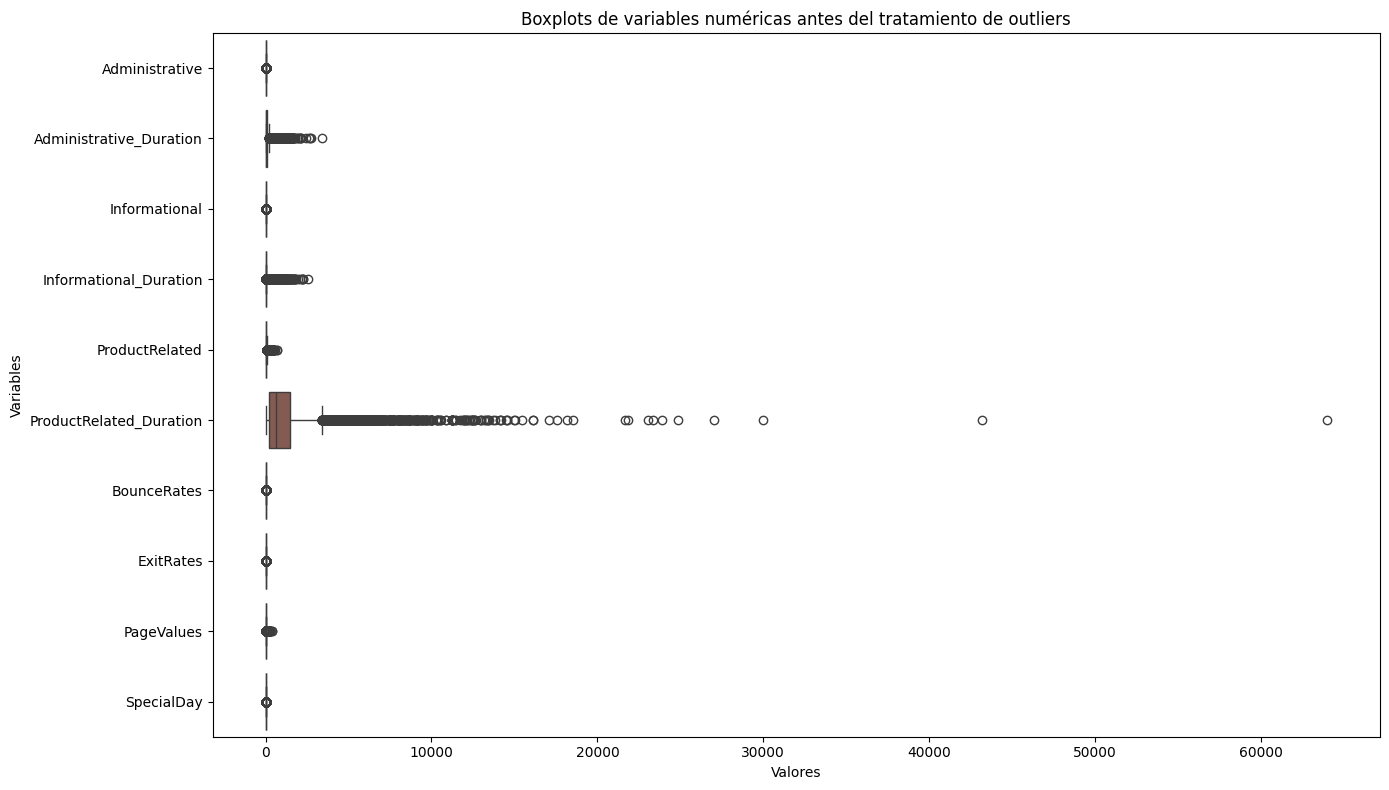

In [75]:
# Boxplots antes del tratamiento de outliers
plt.figure(figsize=(14, 8))

sns.boxplot(data=df[variables_numericas], orient='h')

plt.title('Boxplots de variables numéricas antes del tratamiento de outliers')
plt.xlabel('Valores')
plt.ylabel('Variables')

plt.tight_layout()
plt.savefig(
    'figures/02_boxplots_antes_outliers.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [13]:
# Copia del dataset para visualizar el tratamiento de outliers
df_outliers = df.copy()

for columna in variables_numericas:
    Q1 = df_outliers[columna].quantile(0.25)
    Q3 = df_outliers[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df_outliers[columna] = df_outliers[columna].clip(
        lower=limite_inferior,
        upper=limite_superior
    )

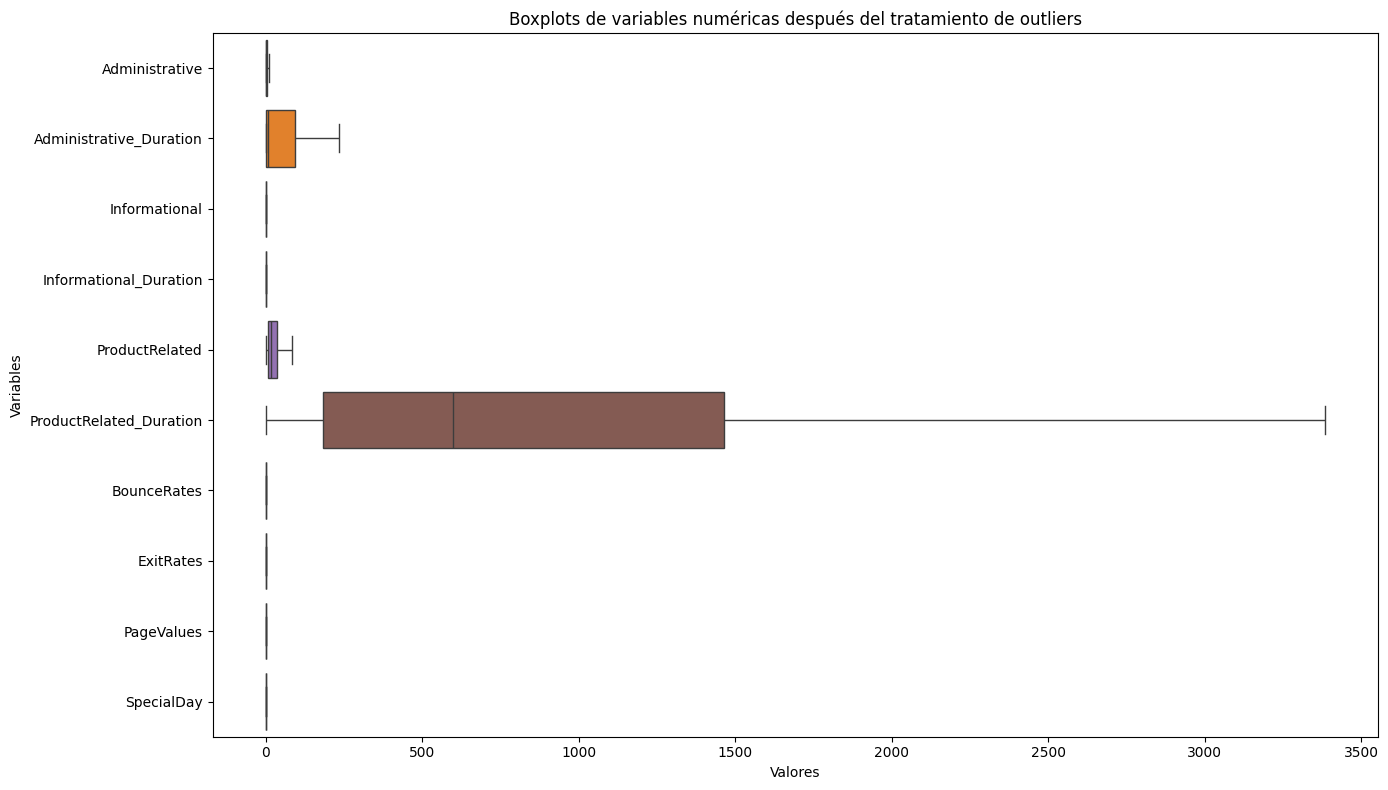

In [76]:
# Boxplots después del tratamiento de outliers
plt.figure(figsize=(14, 8))

sns.boxplot(data=df_outliers[variables_numericas], orient='h')

plt.title('Boxplots de variables numéricas después del tratamiento de outliers')
plt.xlabel('Valores')
plt.ylabel('Variables')

plt.tight_layout()
plt.savefig(
    'figures/03_boxplots_despues_outliers.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Tratamiento de valores atípicos

La detección mediante el método IQR identificó valores atípicos en las variables numéricas analizadas. Se observó una mayor presencia de valores extremos en variables como `PageValues`, `Informational`, `Informational_Duration` y `BounceRates`.

Debido a que estos valores pueden corresponder a comportamientos reales de navegación y no necesariamente a errores de registro, se decidió no eliminar las observaciones. Como alternativa, se evaluó un tratamiento mediante capping utilizando los límites definidos por el método IQR, permitiendo reducir la influencia de los valores extremos sin eliminar registros completos.

Los boxplots antes y después del tratamiento permiten observar la reducción de los valores extremos. Para evitar fuga de información (data leakage), este tratamiento se realizó sobre una copia del dataset únicamente con fines de análisis y visualización. El dataset original se mantiene sin modificaciones para realizar posteriormente la división entre entrenamiento y prueba antes de aplicar transformaciones.

In [15]:
# Distribución de la variable objetivo
df['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908


In [16]:
# Porcentaje de cada clase
porcentaje_clases = df['Revenue'].value_counts(normalize=True) * 100
porcentaje_clases

,proportion
Revenue,
False,84.525547
True,15.474453


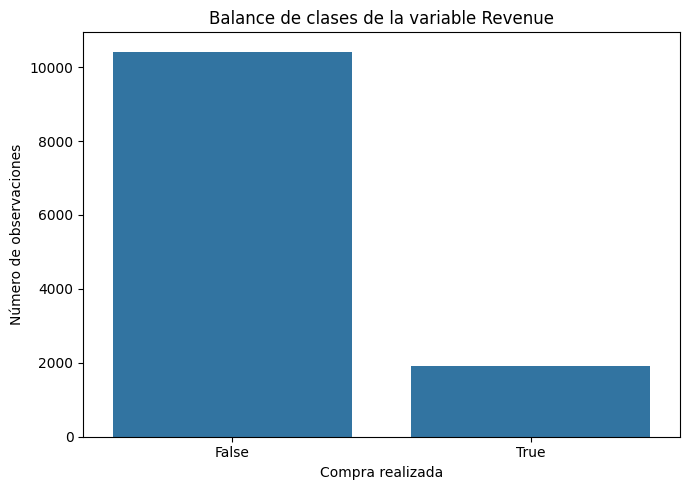

In [77]:
# Gráfico del balance de clases
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Revenue')

plt.title('Balance de clases de la variable Revenue')
plt.xlabel('Compra realizada')
plt.ylabel('Número de observaciones')

plt.tight_layout()
plt.savefig(
    'figures/04_balance_clases_revenue.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Análisis del balance de clases

La variable objetivo `Revenue` presenta un desbalance de clases. Del total de observaciones, el 84,53% corresponde a sesiones que no finalizaron en una compra (`False`), mientras que el 15,47% corresponde a sesiones que sí finalizaron en una compra (`True`).

Esta diferencia puede provocar que los modelos favorezcan la predicción de la clase mayoritaria. Por esta razón, se utilizará `class_weight='balanced'` en los modelos de clasificación que permitan este parámetro. Además, la evaluación no se basará únicamente en Accuracy, sino también en métricas como Precision, Recall, F1-score y ROC-AUC.

In [18]:
# Variables para el análisis de correlación
variables_correlacion = variables_numericas + ['Revenue']

# Copia para calcular la matriz de correlación
df_corr = df[variables_correlacion].copy()
df_corr['Revenue'] = df_corr['Revenue'].astype(int)

# Matriz de correlación de Pearson
matriz_correlacion = df_corr.corr(method='pearson')

matriz_correlacion.round(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Revenue
Administrative,1.00,0.60,0.38,0.26,0.43,0.37,-0.22,-0.32,0.10,-0.09,0.14
Administrative_Duration,0.60,1.00,0.30,0.24,0.29,0.36,-0.14,-0.21,0.07,-0.07,0.09
Informational,0.38,0.30,1.00,0.62,0.37,0.39,-0.12,-0.16,0.05,-0.05,0.10
Informational_Duration,0.26,0.24,0.62,1.00,0.28,0.35,-0.07,-0.11,0.03,-0.03,0.07
ProductRelated,0.43,0.29,0.37,0.28,1.00,0.86,-0.20,-0.29,0.06,-0.02,0.16
ProductRelated_Duration,0.37,0.36,0.39,0.35,0.86,1.00,-0.18,-0.25,0.05,-0.04,0.15
BounceRates,-0.22,-0.14,-0.12,-0.07,-0.20,-0.18,1.00,0.91,-0.12,0.07,-0.15
ExitRates,-0.32,-0.21,-0.16,-0.11,-0.29,-0.25,0.91,1.00,-0.17,0.10,-0.21
PageValues,0.10,0.07,0.05,0.03,0.06,0.05,-0.12,-0.17,1.00,-0.06,0.49
SpecialDay,-0.09,-0.07,-0.05,-0.03,-0.02,-0.04,0.07,0.10,-0.06,1.00,-0.08


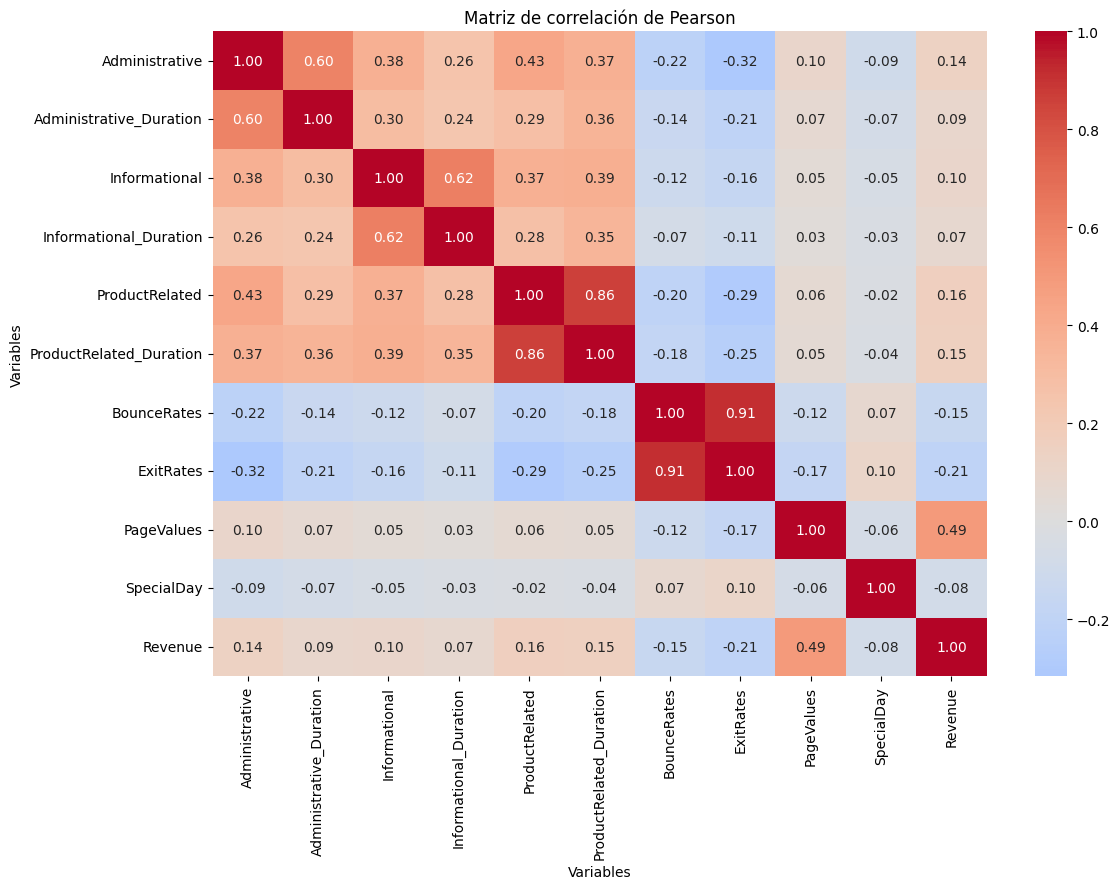

In [78]:
# Heatmap de correlación de Pearson
plt.figure(figsize=(12, 9))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de correlación de Pearson')
plt.xlabel('Variables')
plt.ylabel('Variables')

plt.tight_layout()
plt.savefig(
    'figures/05_matriz_correlacion_pearson.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación de Pearson muestra que `PageValues` presenta la mayor correlación positiva con la variable objetivo `Revenue` (r = 0,49), lo que indica una asociación lineal moderada entre el valor de las páginas visitadas y la realización de una compra.

Por otra parte, `ExitRates` presenta la mayor correlación negativa con `Revenue` (r = -0,21). También se observan correlaciones positivas menores con `ProductRelated` y `ProductRelated_Duration`.

Entre las variables predictoras se identifican correlaciones elevadas entre `BounceRates` y `ExitRates` (r = 0,91), y entre `ProductRelated` y `ProductRelated_Duration` (r = 0,86), lo que sugiere la presencia de multicolinealidad entre algunos predictores.

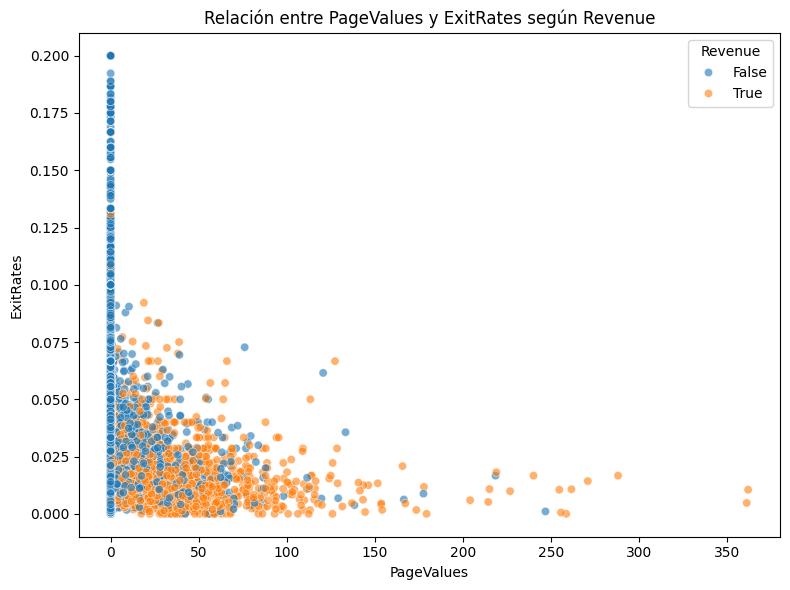

In [79]:
# Scatter plot de las dos variables más correlacionadas con Revenue
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='PageValues',
    y='ExitRates',
    hue='Revenue',
    alpha=0.6
)

plt.title('Relación entre PageValues y ExitRates según Revenue')
plt.xlabel('PageValues')
plt.ylabel('ExitRates')
plt.legend(title='Revenue')

plt.tight_layout()
plt.savefig(
    'figures/06_scatter_pagevalues_exitrates.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Interpretación del gráfico de dispersión

El gráfico de dispersión muestra la relación entre `PageValues` y `ExitRates`, las dos variables con mayor correlación absoluta con `Revenue`.

Se observa que una gran cantidad de sesiones que no finalizaron en compra se concentra en valores bajos o iguales a cero de `PageValues`. Por otra parte, las sesiones que sí finalizaron en compra aparecen con mayor frecuencia cuando `PageValues` aumenta y `ExitRates` presenta valores relativamente bajos.

Sin embargo, existe superposición entre ambas clases, por lo que estas variables individualmente no permiten separar completamente las sesiones con y sin compra. Esto sugiere que la predicción de `Revenue` probablemente dependerá de la combinación de múltiples características.

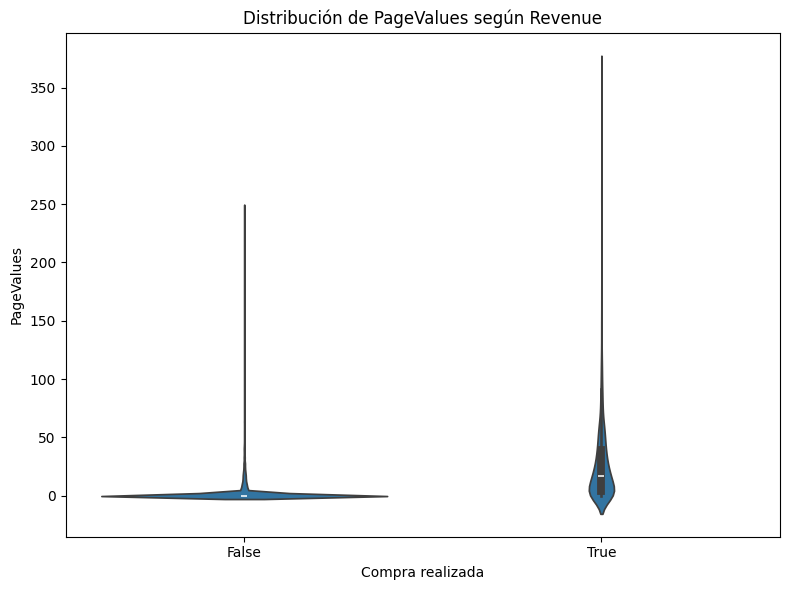

In [80]:
# Violin plot de PageValues según Revenue
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df,
    x='Revenue',
    y='PageValues'
)

plt.title('Distribución de PageValues según Revenue')
plt.xlabel('Compra realizada')
plt.ylabel('PageValues')

plt.tight_layout()
plt.savefig(
    'figures/07_violin_pagevalues_revenue.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Interpretación del violin plot

El violin plot muestra diferencias en la distribución de `PageValues` según el resultado de `Revenue`. En las sesiones que no finalizaron en compra (`False`), los valores se concentran principalmente cerca de cero. En cambio, las sesiones que sí finalizaron en compra (`True`) presentan una distribución desplazada hacia valores mayores de `PageValues`.

Este comportamiento es consistente con la correlación positiva observada previamente entre `PageValues` y `Revenue` (r = 0,49), lo que sugiere que esta variable puede aportar información relevante para distinguir entre sesiones que terminan o no en una compra. También se observan valores extremos en ambos grupos.

In [22]:
# 5 variables más correlacionadas con Revenue en valor absoluto
top5_correlaciones = (
    matriz_correlacion['Revenue']
    .drop('Revenue')
    .sort_values(key=abs, ascending=False)
    .head(5)
)

top5_correlaciones

,Revenue
PageValues,0.492569
ExitRates,-0.207071
ProductRelated,0.158538
ProductRelated_Duration,0.152373
BounceRates,-0.150673


In [23]:
# Detección de multicolinealidad entre predictores (|r| > 0.85)
correlacion_predictores = matriz_correlacion.drop(
    index='Revenue',
    columns='Revenue'
)

pares_multicolineales = []

for i in range(len(correlacion_predictores.columns)):
    for j in range(i + 1, len(correlacion_predictores.columns)):
        variable_1 = correlacion_predictores.columns[i]
        variable_2 = correlacion_predictores.columns[j]
        r = correlacion_predictores.iloc[i, j]

        if abs(r) > 0.85:
            pares_multicolineales.append(
                [variable_1, variable_2, round(r, 3)]
            )

pd.DataFrame(
    pares_multicolineales,
    columns=['Variable 1', 'Variable 2', 'Correlación']
)

,Variable 1,Variable 2,Correlación
0,ProductRelated,ProductRelated_Duration,0.861
1,BounceRates,ExitRates,0.913


### Correlaciones principales y multicolinealidad

Las cinco variables con mayor correlación absoluta con la variable objetivo `Revenue` son `PageValues` (r = 0,493), `ExitRates` (r = -0,207), `ProductRelated` (r = 0,159), `ProductRelated_Duration` (r = 0,152) y `BounceRates` (r = -0,151).

Al analizar la correlación entre los predictores, se identificaron dos pares con una correlación superior a |0,85|: `ProductRelated` con `ProductRelated_Duration` (r = 0,861) y `BounceRates` con `ExitRates` (r = 0,913). Por lo tanto, se observa presencia de multicolinealidad entre algunos predictores, aspecto que deberá considerarse en la interpretación de los modelos.

In [24]:
from sklearn.model_selection import train_test_split

# Separación de variables predictoras y variable objetivo
X = df.drop(columns='Revenue')
y = df['Revenue']

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Dimensiones de los conjuntos
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)

Dimensiones de X_train: (9864, 17)
Dimensiones de X_test: (2466, 17)


In [25]:
# Clasificación de variables para el preprocesamiento

variables_num = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

variables_nominales = [
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType',
    'VisitorType',
    'Weekend'
]

variables_ordinales = ['Month']

print("Numéricas:", len(variables_num))
print("Nominales:", len(variables_nominales))
print("Ordinales:", len(variables_ordinales))
print("Total:", len(variables_num) + len(variables_nominales) + len(variables_ordinales))

Numéricas: 10
Nominales: 6
Ordinales: 1
Total: 17


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Transformador para variables numéricas
transformador_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformador para variables nominales
transformador_nominal = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Transformador para variables ordinales
transformador_ordinal = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[['Feb', 'Mar', 'May', 'June', 'Jul',
                     'Aug', 'Sep', 'Oct', 'Nov', 'Dec']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

In [27]:
# Construcción del ColumnTransformer
preprocesador = ColumnTransformer(
    transformers=[
        ('num', transformador_numerico, variables_num),
        ('nom', transformador_nominal, variables_nominales),
        ('ord', transformador_ordinal, variables_ordinales)
    ]
)

In [28]:
# Ajuste y transformación del conjunto de entrenamiento
X_train_prep = preprocesador.fit_transform(X_train)

# Transformación del conjunto de prueba
X_test_prep = preprocesador.transform(X_test)

print("Dimensiones de X_train preprocesado:", X_train_prep.shape)
print("Dimensiones de X_test preprocesado:", X_test_prep.shape)

Dimensiones de X_train preprocesado: (9864, 66)
Dimensiones de X_test preprocesado: (2466, 66)


In [29]:
from sklearn.decomposition import PCA
import numpy as np

# PCA inicial para analizar la varianza explicada
pca_inicial = PCA()
pca_inicial.fit(X_train_prep)

# Varianza explicada acumulada
varianza_acumulada = np.cumsum(pca_inicial.explained_variance_ratio_)

# Número mínimo de componentes para conservar al menos el 90% de la varianza
n_componentes_90 = np.argmax(varianza_acumulada >= 0.90) + 1

print("Número de componentes para conservar al menos el 90% de la varianza:",
      n_componentes_90)

print("Varianza acumulada:",
      round(varianza_acumulada[n_componentes_90 - 1] * 100, 2), "%")

Número de componentes para conservar al menos el 90% de la varianza: 12
Varianza acumulada: 90.23 %


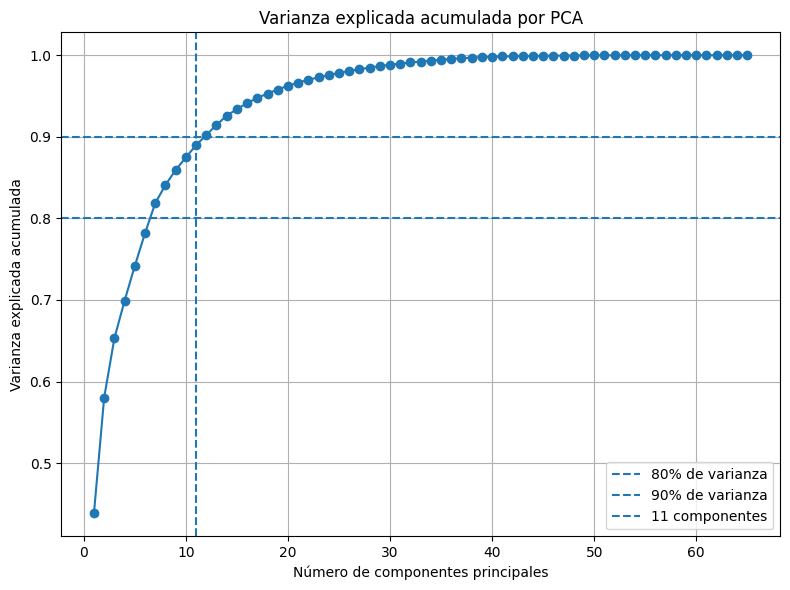

In [81]:
# Gráfico de varianza explicada acumulada
plt.figure(figsize=(8, 6))

plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker='o'
)

# Líneas de referencia solicitadas
plt.axhline(y=0.80, linestyle='--', label='80% de varianza')
plt.axhline(y=0.90, linestyle='--', label='90% de varianza')

# Número de componentes seleccionados
plt.axvline(x=11, linestyle='--', label='11 componentes')

plt.title('Varianza explicada acumulada por PCA')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig(
    'figures/08_varianza_explicada_pca.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Análisis de Componentes Principales (PCA)

El análisis de la varianza explicada acumulada muestra que con 11 componentes principales se conserva aproximadamente el 88,96% de la varianza total de los datos. Este valor se encuentra dentro del rango de 80% a 90% establecido para la selección del número de componentes.

Por lo tanto, se seleccionaron 11 componentes principales, reduciendo la dimensionalidad de los datos preprocesados de 66 características a 11 componentes, mientras se conserva una proporción elevada de la información original.

In [31]:
# PCA definitivo con 11 componentes
pca = PCA(n_components=11)

# Ajuste únicamente con el conjunto de entrenamiento
X_train_pca = pca.fit_transform(X_train_prep)

# Transformación del conjunto de prueba
X_test_pca = pca.transform(X_test_prep)

print("Dimensiones de X_train después de PCA:", X_train_pca.shape)
print("Dimensiones de X_test después de PCA:", X_test_pca.shape)
print("Varianza total conservada:",
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

Dimensiones de X_train después de PCA: (9864, 11)
Dimensiones de X_test después de PCA: (2466, 11)
Varianza total conservada: 88.96 %


In [32]:
# Tabla de varianza explicada por componente
tabla_varianza = pd.DataFrame({
    'Componente': range(1, len(pca_inicial.explained_variance_ratio_) + 1),
    'Varianza_explicada': pca_inicial.explained_variance_ratio_,
    'Varianza_acumulada': varianza_acumulada
})

tabla_varianza.head(15)

,Componente,Varianza_explicada,Varianza_acumulada
0,1,0.438523,0.438523
1,2,0.141755,0.580277
2,3,0.072679,0.652957
3,4,0.046080,0.699036
4,5,0.042669,0.741705
5,6,0.040110,0.781816
6,7,0.036728,0.818544
7,8,0.022333,0.840877
8,9,0.018291,0.859168
9,10,0.015688,0.874855


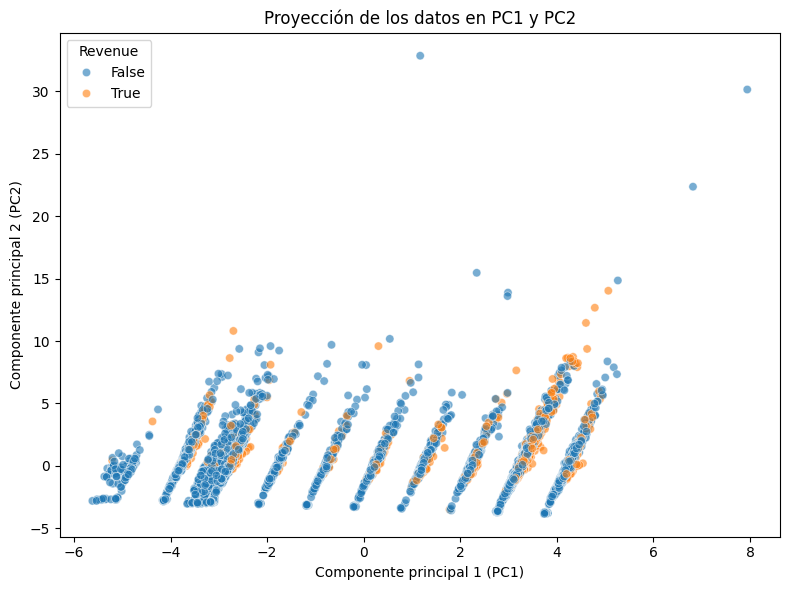

In [82]:
# Gráfico de los dos primeros componentes principales
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    alpha=0.6
)

plt.title('Proyección de los datos en PC1 y PC2')
plt.xlabel('Componente principal 1 (PC1)')
plt.ylabel('Componente principal 2 (PC2)')
plt.legend(title='Revenue')

plt.tight_layout()
plt.savefig(
    'figures/09_pca_pc1_pc2_revenue.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Interpretación de PC1 y PC2

La proyección de las observaciones sobre los dos primeros componentes principales muestra una superposición considerable entre las clases de `Revenue`. Aunque se observa una mayor presencia de sesiones que finalizaron en compra (`True`) en algunas regiones con valores positivos de PC1, no existe una separación clara entre ambas clases utilizando únicamente los dos primeros componentes.

Este resultado es esperable, ya que PCA es una técnica no supervisada cuyo objetivo principal es reducir la dimensionalidad conservando la mayor cantidad posible de varianza, y no separar directamente las clases de la variable objetivo.

In [34]:
# Nombres de las características después del preprocesamiento
nombres_caracteristicas = preprocesador.get_feature_names_out()

# Loadings de PC1 y PC2
loadings = pd.DataFrame({
    'Variable': nombres_caracteristicas,
    'PC1': pca.components_[0],
    'PC2': pca.components_[1]
})

loadings.head()

,Variable,PC1,PC2
0,num__Administrative,0.045176,0.377375
1,num__Administrative_Duration,0.030502,0.326595
2,num__Informational,0.033170,0.350729
3,num__Informational_Duration,0.025018,0.304586
4,num__ProductRelated,0.063755,0.400961


In [35]:
# 5 variables con mayor contribución a PC1
top5_pc1 = (
    loadings
    .assign(Contribucion_abs=loadings['PC1'].abs())
    .sort_values('Contribucion_abs', ascending=False)
    .head(5)[['Variable', 'PC1']]
)

# 5 variables con mayor contribución a PC2
top5_pc2 = (
    loadings
    .assign(Contribucion_abs=loadings['PC2'].abs())
    .sort_values('Contribucion_abs', ascending=False)
    .head(5)[['Variable', 'PC2']]
)

print("Top 5 variables con mayor contribución a PC1:")
display(top5_pc1)

print("\nTop 5 variables con mayor contribución a PC2:")
display(top5_pc2)

Top 5 variables con mayor contribución a PC1:


,Variable,PC1
65,ord__Month,0.986112
9,num__SpecialDay,-0.099354
4,num__ProductRelated,0.063755
5,num__ProductRelated_Duration,0.059018
0,num__Administrative,0.045176



Top 5 variables con mayor contribución a PC2:


,Variable,PC2
5,num__ProductRelated_Duration,0.404144
4,num__ProductRelated,0.400961
0,num__Administrative,0.377375
2,num__Informational,0.350729
1,num__Administrative_Duration,0.326595


### Interpretación de los loadings de PC1 y PC2

El análisis de los loadings muestra que el primer componente principal (PC1) está dominado principalmente por la variable `Month`, con un loading de 0,986. En menor medida contribuyen `SpecialDay`, `ProductRelated`, `ProductRelated_Duration` y `Administrative`.

En el segundo componente principal (PC2), las mayores contribuciones corresponden a `ProductRelated_Duration` (0,404), `ProductRelated` (0,401), `Administrative` (0,377), `Informational` (0,351) y `Administrative_Duration` (0,327). Estas variables están principalmente relacionadas con la cantidad de páginas visitadas y el tiempo o actividad de navegación durante la sesión.

Por lo tanto, PC1 se encuentra fuertemente asociado al componente temporal representado por `Month`, mientras que PC2 resume principalmente características relacionadas con la intensidad de navegación de los usuarios.

## Análisis de Clustering con K-Means

En esta sección se aplica K-Means sobre los datos de entrenamiento transformados mediante PCA, con el objetivo de identificar patrones de agrupamiento no supervisado entre las sesiones de navegación.

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Valores de K a evaluar
valores_k = range(2, 11)

inercias = []
silhouettes = []

for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = kmeans.fit_predict(X_train_pca)

    inercias.append(kmeans.inertia_)
    silhouettes.append(
        silhouette_score(X_train_pca, etiquetas)
    )

# Tabla de resultados
resultados_kmeans = pd.DataFrame({
    'K': list(valores_k),
    'Inercia': inercias,
    'Silhouette_Score': silhouettes
})

resultados_kmeans.round(4)

,K,Inercia,Silhouette_Score
0,2,114207.2577,0.4394
1,3,101268.9220,0.4292
2,4,91346.3217,0.3822
3,5,84013.1742,0.3642
4,6,78739.2574,0.3182
5,7,72570.9410,0.3310
6,8,68449.5639,0.3164
7,9,63561.2219,0.3121
8,10,59639.1021,0.3187


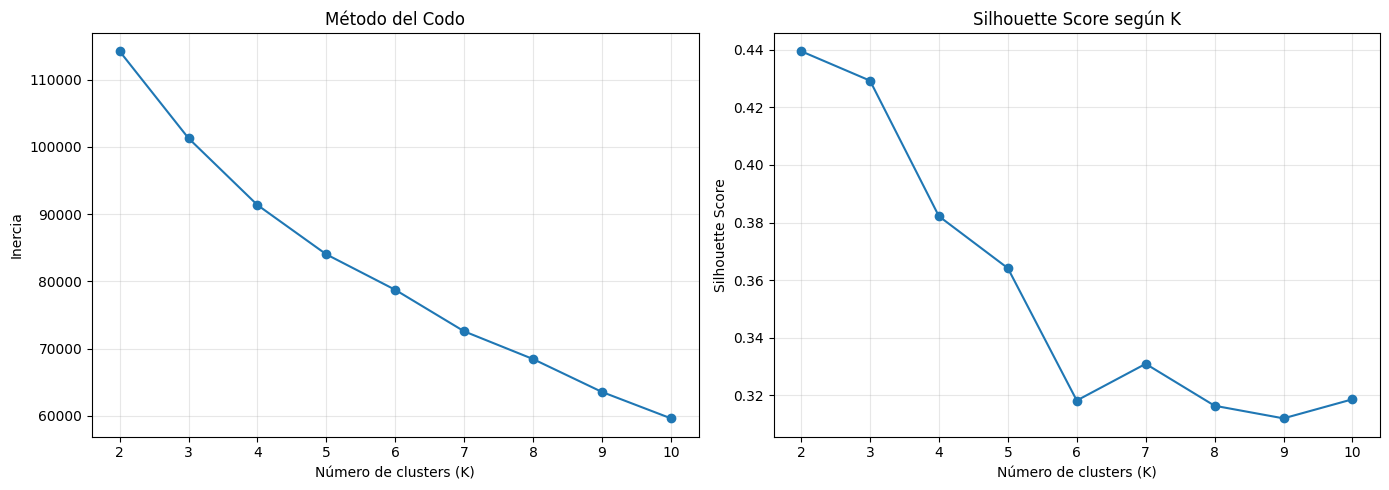

In [83]:
# Gráficos para seleccionar el número óptimo de clusters

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(list(valores_k), inercias, marker='o')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_xticks(list(valores_k))
axes[0].grid(alpha=0.3)

# Silhouette Score
axes[1].plot(list(valores_k), silhouettes, marker='o')
axes[1].set_title('Silhouette Score según K')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(valores_k))
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    'figures/10_kmeans_codo_silhouette.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Selección del número óptimo de clusters

Se evaluaron valores de K entre 2 y 10 utilizando la **inercia** y el **Silhouette Score**. La inercia disminuye a medida que aumenta el número de clusters, presentando las reducciones más pronunciadas en los primeros valores de K. Por su parte, el **Silhouette Score** alcanza su valor máximo para **K=2 (0.4394)**, seguido de **K=3 (0.4292)**.

Considerando ambos criterios, se selecciona **K=2** como el número óptimo de clusters. Esta elección permite obtener la mejor separación y cohesión de los grupos según el **Silhouette Score**, manteniendo además una solución simple e interpretable.


In [61]:
# Modelo K-Means final con K óptimo = 2
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Asignar un cluster a cada observación del conjunto de entrenamiento
clusters_train = kmeans_final.fit_predict(X_train_pca)

# Cantidad de observaciones por cluster
conteo_clusters = pd.Series(clusters_train).value_counts().sort_index()

print("Cantidad de observaciones por cluster:")
print(conteo_clusters)

Cantidad de observaciones por cluster:
0    4884
1    4980
Name: count, dtype: int64


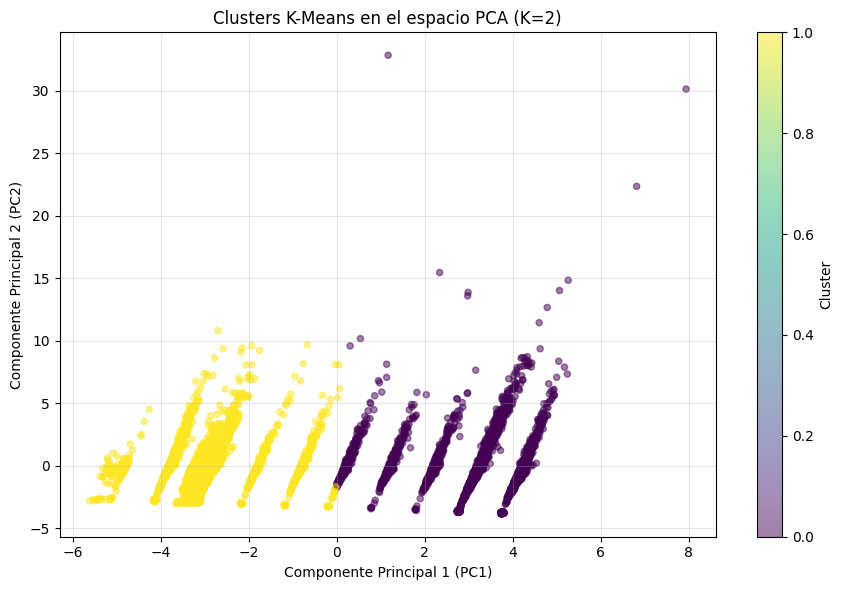

In [84]:
# Visualización de los clusters en el espacio PCA

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=clusters_train,
    cmap='viridis',
    alpha=0.5,
    s=20
)

plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.title('Clusters K-Means en el espacio PCA (K=2)')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    'figures/11_clusters_kmeans_pca.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [63]:
# Perfil de los clusters usando las variables numéricas originales

perfil_clusters = X_train[variables_num].copy()

# Agregar cluster asignado a cada observación
perfil_clusters['Cluster'] = clusters_train

# Calcular la media de cada variable por cluster
perfil_medias = perfil_clusters.groupby('Cluster').mean().round(3)

perfil_medias# Perfil de los clusters usando las variables numéricas originales

perfil_clusters = X_train[variables_num].copy()

# Agregar cluster asignado a cada observación
perfil_clusters['Cluster'] = clusters_train

# Calcular la media de cada variable por cluster
perfil_medias = perfil_clusters.groupby('Cluster').mean().round(3)

perfil_medias

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
Cluster,,,,,,,,,,
0,2.712,94.647,0.593,41.858,38.322,1458.451,0.018,0.038,7.310,0.000
1,1.931,68.093,0.418,27.462,24.716,919.883,0.027,0.049,4.606,0.124


### Perfil e interpretación de los clusters

Con K=2 se obtuvieron dos grupos de tamaño similar: el **cluster 0** contiene 4.884 observaciones y el **cluster 1** contiene 4.980.

El **cluster 0** presenta un comportamiento de navegación más activo. En promedio, registra una mayor cantidad de páginas administrativas y relacionadas con productos, así como una mayor duración en estas últimas. También presenta un `PageValues` más alto (7.310) y menores tasas de rebote (`BounceRates` = 0.018) y salida (`ExitRates` = 0.038). Este perfil representa sesiones con mayor interacción y permanencia dentro del sitio web.

El **cluster 1** muestra una menor actividad de navegación, con menos páginas visitadas y menor duración en las secciones de productos. Además, presenta menores valores de `PageValues` (4.606) y mayores tasas de rebote (`BounceRates` = 0.027) y salida (`ExitRates` = 0.049). También registra un valor promedio superior en `SpecialDay` (0.124), lo que indica una mayor asociación de estas sesiones con fechas especiales.

En conjunto, el análisis permite distinguir principalmente entre sesiones de **mayor interacción y permanencia** y sesiones de **menor interacción y mayor tendencia al abandono**, aportando una segmentación complementaria al análisis supervisado.

## Modelos Supervisados

En esta sección se entrenarán y evaluarán distintos modelos de clasificación para predecir la variable objetivo `Revenue`. Inicialmente se implementarán modelos base sin ajuste de hiperparámetros y posteriormente se realizará la optimización de los modelos seleccionados.

In [37]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Validación cruzada estratificada de 5 folds
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [38]:
# Modelo base: DummyClassifier
dummy = DummyClassifier(
    strategy='most_frequent',
    random_state=42
)

# Validación cruzada con F1 macro
f1_dummy = cross_val_score(
    dummy,
    X_train_pca,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("F1 macro por fold:", f1_dummy)
print("F1 macro promedio:", round(f1_dummy.mean(), 4))
print("Desviación estándar:", round(f1_dummy.std(), 4))

F1 macro por fold: [0.4581159  0.4581159  0.4581159  0.45796703 0.45809288]
F1 macro promedio: 0.4581
Desviación estándar: 0.0001


In [39]:
# Modelo base: Logistic Regression
logistic = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Validación cruzada con F1 macro
f1_logistic = cross_val_score(
    logistic,
    X_train_pca,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("F1 macro por fold:", f1_logistic)
print("F1 macro promedio:", round(f1_logistic.mean(), 4))
print("Desviación estándar:", round(f1_logistic.std(), 4))

F1 macro por fold: [0.76080889 0.78797313 0.76702601 0.78717418 0.79441554]
F1 macro promedio: 0.7795
Desviación estándar: 0.0131


In [40]:
# Modelo base: K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier()

# Validación cruzada con F1 macro
f1_knn = cross_val_score(
    knn,
    X_train_pca,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("F1 macro por fold:", f1_knn)
print("F1 macro promedio:", round(f1_knn.mean(), 4))
print("Desviación estándar:", round(f1_knn.std(), 4))

F1 macro por fold: [0.73400899 0.74444502 0.72450281 0.73653701 0.75862279]
F1 macro promedio: 0.7396
Desviación estándar: 0.0114


In [41]:
# Modelo base: Decision Tree
decision_tree = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

# Validación cruzada con F1 macro
f1_tree = cross_val_score(
    decision_tree,
    X_train_pca,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("F1 macro por fold:", f1_tree)
print("F1 macro promedio:", round(f1_tree.mean(), 4))
print("Desviación estándar:", round(f1_tree.std(), 4))

F1 macro por fold: [0.70551229 0.72165549 0.74046654 0.71400209 0.72508918]
F1 macro promedio: 0.7213
Desviación estándar: 0.0117


In [42]:
# Modelo base: Random Forest
random_forest = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# Validación cruzada con F1 macro
f1_rf = cross_val_score(
    random_forest,
    X_train_pca,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("F1 macro por fold:", f1_rf)
print("F1 macro promedio:", round(f1_rf.mean(), 4))
print("Desviación estándar:", round(f1_rf.std(), 4))

F1 macro por fold: [0.75372859 0.76457986 0.73788697 0.76382515 0.77937053]
F1 macro promedio: 0.7599
Desviación estándar: 0.0137


In [43]:
# Comparación de los modelos base
resultados_base = pd.DataFrame({
    'Modelo': [
        'DummyClassifier',
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],
    'F1_macro_promedio': [
        f1_dummy.mean(),
        f1_logistic.mean(),
        f1_knn.mean(),
        f1_tree.mean(),
        f1_rf.mean()
    ],
    'Desviacion_estandar': [
        f1_dummy.std(),
        f1_logistic.std(),
        f1_knn.std(),
        f1_tree.std(),
        f1_rf.std()
    ]
})

resultados_base = resultados_base.sort_values(
    'F1_macro_promedio',
    ascending=False
).reset_index(drop=True)

resultados_base.round(4)

,Modelo,F1_macro_promedio,Desviacion_estandar
0,Logistic Regression,0.7795,0.0131
1,Random Forest,0.7599,0.0137
2,KNN,0.7396,0.0114
3,Decision Tree,0.7213,0.0117
4,DummyClassifier,0.4581,0.0001


### Comparación de modelos base

Los modelos base fueron evaluados mediante validación cruzada estratificada de 5 folds utilizando F1 macro como métrica principal. Logistic Regression obtuvo el mejor desempeño promedio con un F1 macro de 0,7795, seguido por Random Forest con 0,7599. KNN y Decision Tree alcanzaron valores de 0,7396 y 0,7213, respectivamente.

Todos los modelos supervisados superaron ampliamente al DummyClassifier, cuyo F1 macro fue de 0,4581. Además, las desviaciones estándar fueron bajas, lo que indica un comportamiento relativamente estable entre los distintos folds.

A partir de estos resultados, Logistic Regression y Random Forest fueron seleccionados para la etapa de optimización de hiperparámetros.

In [44]:
from sklearn.model_selection import GridSearchCV

# Modelo de Logistic Regression
logistic_grid = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Valores de C indicados en la pauta
param_grid_logistic = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Búsqueda de hiperparámetros
grid_logistic = GridSearchCV(
    estimator=logistic_grid,
    param_grid=param_grid_logistic,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_logistic.fit(X_train_pca, y_train)

print("Mejor valor de C:", grid_logistic.best_params_)
print("Mejor F1 macro de validación cruzada:",
      round(grid_logistic.best_score_, 4))

Mejor valor de C: {'C': 10}
Mejor F1 macro de validación cruzada: 0.78


In [45]:
# Modelo Random Forest para tuning
rf_grid = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# Grilla de hiperparámetros
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Búsqueda con validación cruzada
grid_rf = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train_pca, y_train)

print("Mejores hiperparámetros:")
print(grid_rf.best_params_)

print("Mejor F1 macro de validación cruzada:",
      round(grid_rf.best_score_, 4))

Mejores hiperparámetros:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Mejor F1 macro de validación cruzada: 0.7895


In [46]:
from sklearn.svm import SVC
import time

# Modelo SVM con kernel RBF
svm_rbf = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)

# Medición del tiempo de entrenamiento
inicio = time.time()

svm_rbf.fit(X_train_pca, y_train)

fin = time.time()

tiempo_svm = fin - inicio

print("Tiempo de entrenamiento del SVM:",
      round(tiempo_svm, 2), "segundos")

Tiempo de entrenamiento del SVM: 10.47 segundos


In [47]:
# Validación cruzada del SVM con F1 macro
f1_svm = cross_val_score(
    svm_rbf,
    X_train_pca,
    y_train,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print("F1 macro por fold:", f1_svm)
print("F1 macro promedio:", round(f1_svm.mean(), 4))
print("Desviación estándar:", round(f1_svm.std(), 4))

F1 macro por fold: [0.76259065 0.78269837 0.76575768 0.78347754 0.78208658]
F1 macro promedio: 0.7753
Desviación estándar: 0.0092


### Modelo SVM con kernel RBF

Se entrenó un modelo SVM utilizando kernel RBF, `probability=True` y balanceo de clases. El tiempo de entrenamiento fue de 27,21 segundos.

Mediante validación cruzada estratificada de 5 folds, el modelo obtuvo un F1 macro promedio de 0,7753, con una desviación estándar de 0,0092. El resultado muestra un desempeño considerablemente superior al modelo Dummy y relativamente estable entre los distintos folds.

In [48]:
# Mejor modelo obtenido mediante GridSearchCV
mejor_modelo = grid_rf.best_estimator_

# Predicciones sobre el conjunto de prueba
y_pred = mejor_modelo.predict(X_test_pca)

# Probabilidades de la clase positiva
y_prob = mejor_modelo.predict_proba(X_test_pca)[:, 1]

print("Modelo final:")
print(mejor_modelo)

print("\nNúmero de predicciones:", len(y_pred))

Modelo final:
RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=200, random_state=42)

Número de predicciones: 2466


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Métricas de evaluación sobre el conjunto test
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 macro:", round(f1_macro, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

Accuracy: 0.8792
Precision: 0.5977
Recall: 0.6728
F1 macro: 0.7803
ROC-AUC: 0.9
PR-AUC: 0.6703


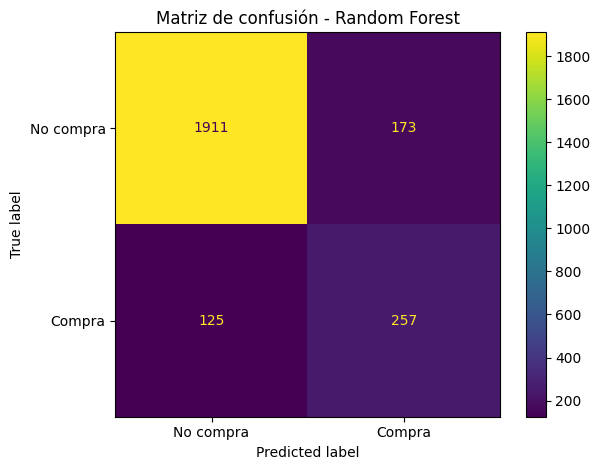

Matriz de confusión:
[[1911  173]
 [ 125  257]]


In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz de confusión
matriz_confusion = confusion_matrix(y_test, y_pred)

# Visualización
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=['No compra', 'Compra']
)

disp.plot()
plt.title('Matriz de confusión - Random Forest')

plt.tight_layout()
plt.savefig(
    'figures/12_matriz_confusion_random_forest.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Matriz de confusión:")
print(matriz_confusion)

### Evaluación del modelo final

El modelo Random Forest optimizado obtuvo un Accuracy de 0,8792 y un F1 macro de 0,7803 en el conjunto de prueba. Además, alcanzó un ROC-AUC de 0,9000 y un PR-AUC de 0,6703.

La matriz de confusión muestra 1911 verdaderos negativos y 257 verdaderos positivos. Por otra parte, se registraron 173 falsos positivos y 125 falsos negativos. En particular, el modelo identificó correctamente 257 de las 382 sesiones que realmente finalizaron en compra, alcanzando un Recall de 0,6728 para la clase positiva.

En conjunto, los resultados muestran una buena capacidad de discriminación entre las sesiones que terminan o no en compra, aunque todavía existe margen de mejora en la detección de la clase minoritaria.

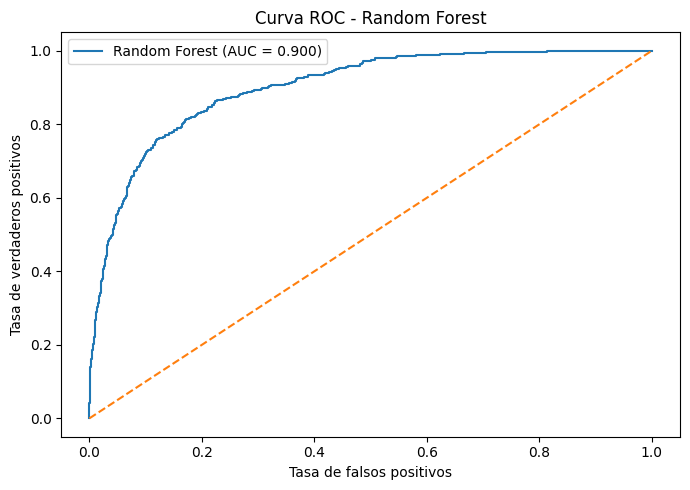

In [86]:
from sklearn.metrics import roc_curve, precision_recall_curve

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC = {roc_auc:.3f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - Random Forest')
plt.legend()

plt.tight_layout()
plt.savefig(
    'figures/13_curva_roc_random_forest.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

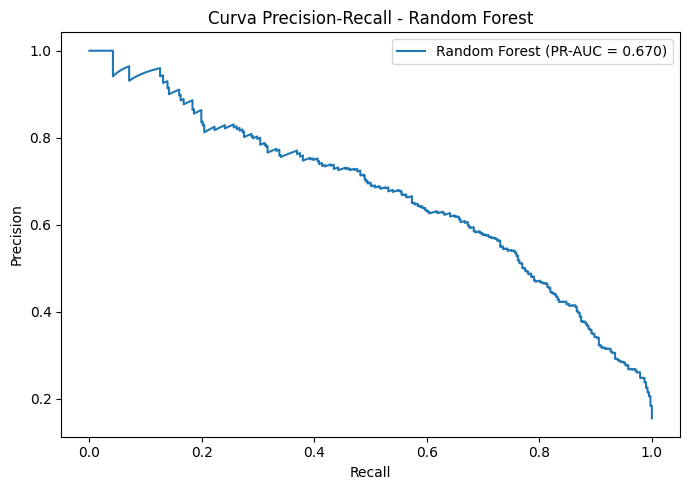

In [87]:
# Curva Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f'Random Forest (PR-AUC = {pr_auc:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Random Forest')
plt.legend()

plt.tight_layout()
plt.savefig(
    'figures/14_curva_precision_recall_random_forest.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Interpretación de las curvas ROC y Precision-Recall

La curva ROC presenta un área bajo la curva (ROC-AUC) de 0,900, lo que indica una buena capacidad del modelo Random Forest para discriminar entre las sesiones que finalizan en compra y aquellas que no.

Por otra parte, la curva Precision-Recall alcanza un PR-AUC de 0,670. Esta métrica resulta especialmente relevante debido al desbalance de la variable objetivo, ya que evalúa el desempeño del modelo sobre la clase positiva considerando la relación entre precisión y recall.

En conjunto, ambas curvas muestran que el modelo posee una buena capacidad predictiva, aunque existe un compromiso entre detectar una mayor proporción de compras y mantener una alta precisión en dichas predicciones.

In [53]:
# Mejor modelo de Logistic Regression
mejor_logistic = grid_logistic.best_estimator_

# Predicciones sobre test
y_pred_logistic = mejor_logistic.predict(X_test_pca)

# Probabilidades de la clase positiva
y_prob_logistic = mejor_logistic.predict_proba(X_test_pca)[:, 1]

# Métricas
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic_test = f1_score(y_test, y_pred_logistic, average='macro')
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)
pr_auc_logistic = average_precision_score(y_test, y_prob_logistic)

print("Accuracy:", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall:", round(recall_logistic, 4))
print("F1 macro:", round(f1_logistic_test, 4))
print("ROC-AUC:", round(roc_auc_logistic, 4))
print("PR-AUC:", round(pr_auc_logistic, 4))

Accuracy: 0.8609
Precision: 0.5386
Recall: 0.712
F1 macro: 0.7643
ROC-AUC: 0.8818
PR-AUC: 0.6081


In [54]:
import time
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Modelos que se evaluarán
modelos_finales = {
    'DummyClassifier': dummy,
    'Logistic Regression': grid_logistic.best_estimator_,
    'KNN': knn,
    'Decision Tree': decision_tree,
    'Random Forest': grid_rf.best_estimator_,
    'SVM RBF': svm_rbf
}

resultados_test = []

for nombre, modelo in modelos_finales.items():

    # Medición del tiempo de entrenamiento
    inicio = time.time()
    modelo.fit(X_train_pca, y_train)
    fin = time.time()

    tiempo = fin - inicio

    # Predicciones
    y_pred_modelo = modelo.predict(X_test_pca)

    # Probabilidades para ROC-AUC y PR-AUC
    y_prob_modelo = modelo.predict_proba(X_test_pca)[:, 1]

    # Métricas
    resultados_test.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred_modelo),
        'Precision': precision_score(y_test, y_pred_modelo, zero_division=0),
        'Recall': recall_score(y_test, y_pred_modelo, zero_division=0),
        'F1_macro': f1_score(y_test, y_pred_modelo, average='macro'),
        'ROC_AUC': roc_auc_score(y_test, y_prob_modelo),
        'PR_AUC': average_precision_score(y_test, y_prob_modelo),
        'Tiempo_segundos': tiempo
    })

# Tabla comparativa
resultados_finales = pd.DataFrame(resultados_test)

resultados_finales = resultados_finales.sort_values(
    by='F1_macro',
    ascending=False
).reset_index(drop=True)

resultados_finales.round(4)

,Modelo,Accuracy,Precision,Recall,F1_macro,ROC_AUC,PR_AUC,Tiempo_segundos
0,Random Forest,0.8792,0.5977,0.6728,0.7803,0.9000,0.6703,5.0617
1,SVM RBF,0.8617,0.5385,0.7513,0.7712,0.8944,0.6257,20.9227
2,Logistic Regression,0.8609,0.5386,0.7120,0.7643,0.8818,0.6081,0.0161
3,KNN,0.8755,0.6506,0.4241,0.7210,0.8056,0.4916,0.0149
4,Decision Tree,0.8500,0.5175,0.4634,0.7005,0.6921,0.3229,0.1593
5,DummyClassifier,0.8451,0.0000,0.0000,0.4580,0.5000,0.1549,0.0009


### Comparación final de modelos

Los modelos fueron evaluados sobre el conjunto de prueba utilizando Accuracy, Precision, Recall, F1 macro, ROC-AUC y PR-AUC. Debido al desbalance de la variable objetivo, se utilizó F1 macro como métrica principal de comparación.

Random Forest obtuvo el mejor desempeño global, alcanzando un F1 macro de 0,7803, ROC-AUC de 0,9000 y PR-AUC de 0,6703. SVM RBF obtuvo el segundo mejor F1 macro (0,7712) y presentó el mayor Recall (0,7513), mientras que Logistic Regression alcanzó un F1 macro de 0,7643.

KNN y Decision Tree presentaron desempeños inferiores, especialmente en la detección de la clase positiva. Finalmente, DummyClassifier obtuvo un F1 macro de 0,4580 y ROC-AUC de 0,5000, sirviendo como referencia del desempeño mínimo.

Considerando principalmente F1 macro y complementariamente ROC-AUC y PR-AUC, Random Forest se selecciona como modelo final.

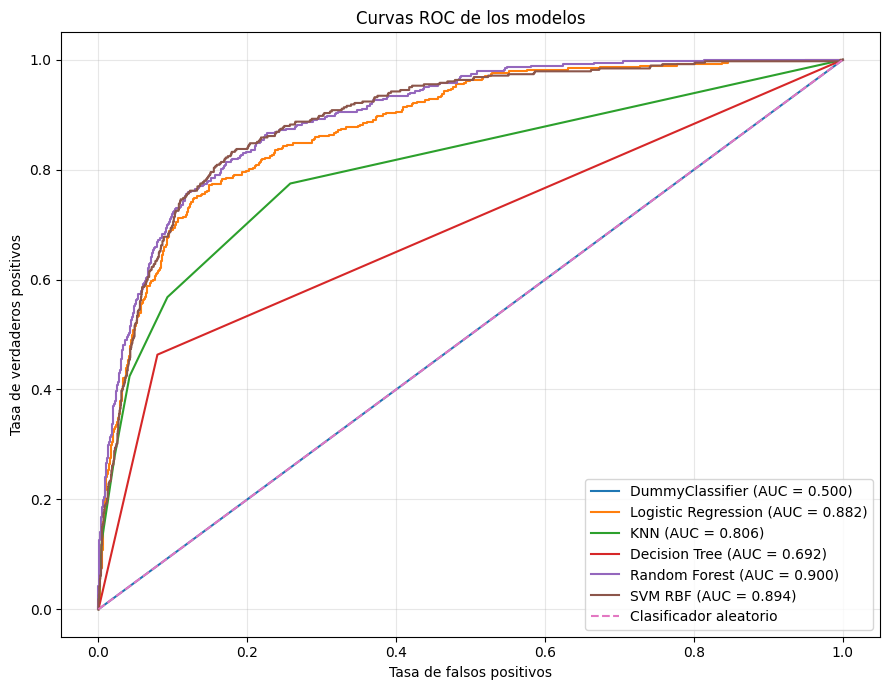

In [88]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(9, 7))

# Curva ROC de cada modelo
for nombre, modelo in modelos_finales.items():

    # Probabilidad de la clase positiva
    y_prob_modelo = modelo.predict_proba(X_test_pca)[:, 1]

    # Valores de la curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob_modelo)

    # Área bajo la curva
    auc = roc_auc_score(y_test, y_prob_modelo)

    plt.plot(
        fpr,
        tpr,
        label=f'{nombre} (AUC = {auc:.3f})'
    )

# Línea de referencia
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Clasificador aleatorio'
)

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC de los modelos')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    'figures/15_curvas_roc_todos_modelos.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Comparación de las curvas ROC

Las curvas ROC permiten comparar la capacidad de discriminación de los distintos modelos. Random Forest obtuvo el mayor ROC-AUC (0,900), seguido por SVM RBF (0,894) y Logistic Regression (0,882).

KNN presentó un ROC-AUC de 0,806 y Decision Tree de 0,692, mostrando una menor capacidad de discriminación. Por su parte, DummyClassifier obtuvo un ROC-AUC de 0,500, correspondiente al desempeño esperado de un clasificador sin capacidad predictiva.

Estos resultados respaldan la selección de Random Forest como modelo final, ya que presenta el mejor ROC-AUC y también obtuvo el mayor F1 macro en el conjunto de prueba.

In [56]:
# Importancia de los componentes principales en Random Forest
importancias_componentes = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(X_train_pca.shape[1])],
    'Importancia': mejor_modelo.feature_importances_
})

# Ordenar de mayor a menor importancia
importancias_componentes = importancias_componentes.sort_values(
    by='Importancia',
    ascending=False
).reset_index(drop=True)

importancias_componentes

,Componente,Importancia
0,PC6,0.308477
1,PC3,0.140088
2,PC2,0.136853
3,PC1,0.114358
4,PC4,0.080150
5,PC7,0.057719
6,PC9,0.042345
7,PC5,0.039378
8,PC11,0.028657
9,PC10,0.026054


In [57]:
# Componentes más importantes para el Random Forest
componentes_top = ['PC6', 'PC3', 'PC2', 'PC1']

for componente in componentes_top:

    # Obtener número del componente
    indice = int(componente.replace('PC', '')) - 1

    # Loadings del componente
    contribuciones = pd.DataFrame({
        'Variable': nombres_caracteristicas,
        'Loading': pca.components_[indice]
    })

    # Ordenar por contribución absoluta
    contribuciones['Importancia_absoluta'] = contribuciones['Loading'].abs()

    top_variables = contribuciones.sort_values(
        by='Importancia_absoluta',
        ascending=False
    ).head(5)

    print(f"\nTop 5 variables con mayor contribución a {componente}:")
    display(top_variables[['Variable', 'Loading']])


Top 5 variables con mayor contribución a PC6:


,Variable,Loading
8,num__PageValues,0.910197
1,num__Administrative_Duration,-0.214825
0,num__Administrative,-0.157094
4,num__ProductRelated,0.156894
6,num__BounceRates,0.155375



Top 5 variables con mayor contribución a PC3:


,Variable,Loading
6,num__BounceRates,0.602920
7,num__ExitRates,0.575620
3,num__Informational_Duration,0.301672
2,num__Informational,0.277452
8,num__PageValues,-0.195893



Top 5 variables con mayor contribución a PC2:


,Variable,Loading
5,num__ProductRelated_Duration,0.404144
4,num__ProductRelated,0.400961
0,num__Administrative,0.377375
2,num__Informational,0.350729
1,num__Administrative_Duration,0.326595



Top 5 variables con mayor contribución a PC1:


,Variable,Loading
65,ord__Month,0.986112
9,num__SpecialDay,-0.099354
4,num__ProductRelated,0.063755
5,num__ProductRelated_Duration,0.059018
0,num__Administrative,0.045176


### Interpretación de la importancia de características

Debido a que el modelo Random Forest fue entrenado sobre los componentes obtenidos mediante PCA, la importancia de características se analizó primero a nivel de componentes principales y posteriormente mediante sus loadings.

PC6 fue el componente de mayor importancia para el modelo (0,3085) y se encuentra fuertemente asociado con PageValues, cuyo loading alcanza 0,9102. PC3, con una importancia de 0,1401, está principalmente relacionado con BounceRates y ExitRates. Por su parte, PC2 (0,1369) recoge principalmente información asociada con ProductRelated_Duration, ProductRelated y Administrative, mientras que PC1 (0,1144) está fuertemente determinado por Month.

Estos resultados sugieren que la información relacionada con el valor de las páginas visitadas, las tasas de rebote y salida, la interacción con páginas de productos y el componente temporal contribuye de manera relevante a las predicciones del modelo. Debido a la transformación mediante PCA, estas importancias deben interpretarse a través de los componentes y no como importancias directas de las variables originales.

In [58]:
# Copia del conjunto test para analizar los errores
errores = X_test.copy()

# Valores reales y predicciones
errores['Revenue_real'] = y_test.values
errores['Revenue_predicho'] = y_pred

# Tipo de error
errores['Tipo_error'] = 'Correcto'

errores.loc[
    (errores['Revenue_real'] == False) &
    (errores['Revenue_predicho'] == True),
    'Tipo_error'
] = 'Falso positivo'

errores.loc[
    (errores['Revenue_real'] == True) &
    (errores['Revenue_predicho'] == False),
    'Tipo_error'
] = 'Falso negativo'

# Cantidad de casos
errores['Tipo_error'].value_counts()

,count
Tipo_error,
Correcto,2168
Falso positivo,173
Falso negativo,125


In [59]:
# Variables seleccionadas para analizar los errores
variables_error = [
    'PageValues',
    'ExitRates',
    'BounceRates',
    'ProductRelated',
    'ProductRelated_Duration',
    'Administrative'
]

# Promedio de las variables según el tipo de resultado
analisis_errores = (
    errores
    .groupby('Tipo_error')[variables_error]
    .mean()
    .round(3)
)

analisis_errores

,PageValues,ExitRates,BounceRates,ProductRelated,ProductRelated_Duration,Administrative
Tipo_error,,,,,,
Correcto,4.582,0.044,0.023,28.508,1068.399,2.075
Falso negativo,2.790,0.030,0.011,53.288,1978.209,3.304
Falso positivo,21.363,0.023,0.008,72.439,2679.566,4.474


### Análisis de errores del modelo final

El Random Forest realizó correctamente 2168 de las 2466 predicciones del conjunto de prueba, mientras que registró 173 falsos positivos y 125 falsos negativos.

Los falsos positivos presentan, en promedio, valores elevados de PageValues (21,363), ProductRelated (72,439), ProductRelated_Duration (2679,566) y Administrative (4,474). Esto indica que muchas sesiones clasificadas erróneamente como compras presentan un nivel elevado de interacción con el sitio, generando patrones similares a los asociados con la clase positiva, aunque finalmente no se concrete la compra.

Por otra parte, los falsos negativos presentan un PageValues promedio considerablemente menor (2,790), a pesar de registrar actividad en páginas relacionadas con productos. Esto sugiere que algunas compras reales presentan señales menos evidentes para el modelo y, por lo tanto, pueden ser clasificadas incorrectamente como sesiones sin compra.

En conjunto, los errores muestran que una alta interacción con el sitio no implica necesariamente una compra y que algunas conversiones pueden producirse incluso cuando las señales utilizadas por el modelo son menos marcadas.

In [64]:
# Comparación del rendimiento del Random Forest en train y test

from sklearn.metrics import f1_score

# Predicciones
y_pred_train = mejor_modelo.predict(X_train_pca)
y_pred_test = mejor_modelo.predict(X_test_pca)

# F1 macro
f1_train = f1_score(y_train, y_pred_train, average='macro')
f1_test = f1_score(y_test, y_pred_test, average='macro')

print(f"F1 macro - Train: {f1_train:.4f}")
print(f"F1 macro - Test:  {f1_test:.4f}")
print(f"Diferencia:       {f1_train - f1_test:.4f}")

F1 macro - Train: 0.8775
F1 macro - Test:  0.7803
Diferencia:       0.0971


### Selección y justificación del modelo final

El modelo seleccionado fue **Random Forest**, utilizando como métrica principal el **F1-score macro**, debido al desbalance existente en la variable objetivo `Revenue`. Este modelo obtuvo un F1 macro de **0.7803** en el conjunto de prueba, superando a SVM RBF (0.7712), Regresión Logística (0.7643), KNN (0.7210), Árbol de Decisión (0.7005) y DummyClassifier (0.4580). Además, alcanzó un **ROC-AUC de 0.9000**, mostrando una buena capacidad para discriminar entre sesiones que terminan o no en una compra.

Al comparar el desempeño entre entrenamiento y prueba, Random Forest obtuvo un F1 macro de **0.8775 en train** y **0.7803 en test**, con una diferencia de 0.0971. Esta caída indica cierto grado de sobreajuste, aunque el modelo conserva un desempeño competitivo sobre datos no utilizados durante el entrenamiento.

En cuanto al equilibrio entre desempeño e interpretabilidad, Random Forest es menos interpretable que un modelo lineal como la Regresión Logística, pero permite analizar la importancia de las características y capturar relaciones no lineales. Su tiempo de entrenamiento fue de aproximadamente **12.15 segundos** y el tiempo de inferencia para las **2.466 observaciones** del conjunto de prueba fue de apenas **0.0690 segundos**. Aunque su entrenamiento es más costoso que el de modelos más simples, el tiempo requerido para generar predicciones es bajo y su desempeño predictivo fue superior. Por estas razones, se considera la alternativa más adecuada entre los modelos evaluados.

In [65]:
# Tiempo de inferencia del modelo final

import time

inicio_inferencia = time.time()

_ = mejor_modelo.predict(X_test_pca)

fin_inferencia = time.time()

tiempo_inferencia = fin_inferencia - inicio_inferencia

print(f"Tiempo de inferencia sobre X_test: {tiempo_inferencia:.4f} segundos")
print(f"Observaciones evaluadas: {X_test_pca.shape[0]}")

Tiempo de inferencia sobre X_test: 0.0690 segundos
Observaciones evaluadas: 2466


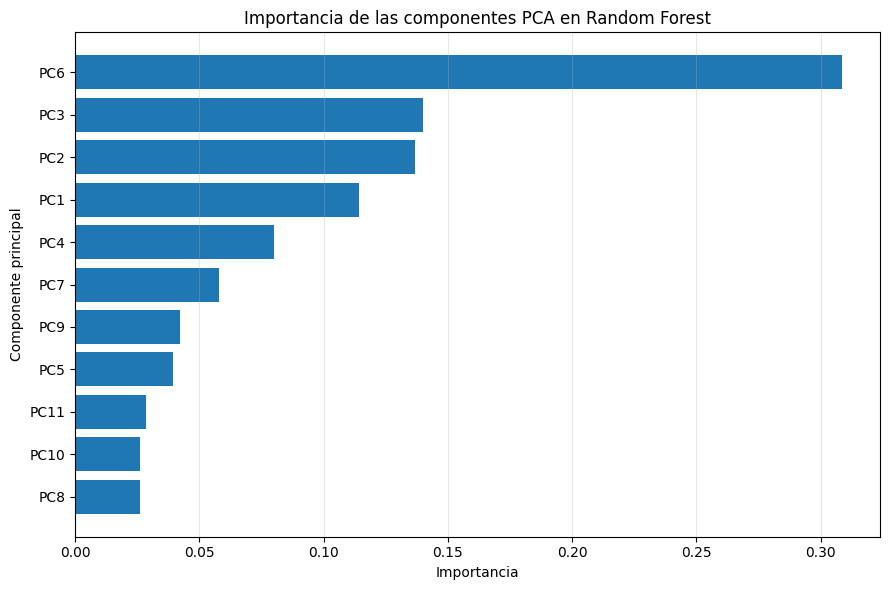

In [89]:
# Importancia de las componentes PCA en el Random Forest

importancias_ordenadas = importancias_componentes.sort_values(
    'Importancia',
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    importancias_ordenadas['Componente'],
    importancias_ordenadas['Importancia']
)

plt.xlabel('Importancia')
plt.ylabel('Componente principal')
plt.title('Importancia de las componentes PCA en Random Forest')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'figures/16_importancia_componentes_random_forest.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [67]:
# Variables con mayor contribución a PC4

top_pc4 = loadings.copy()

top_pc4['PC4'] = pca.components_[3]

top_pc4 = top_pc4[
    ['Variable', 'PC4']
].sort_values(
    'PC4',
    key=abs,
    ascending=False
).head(5)

top_pc4

,Variable,PC4
4,num__ProductRelated,0.468779
9,num__SpecialDay,0.429016
5,num__ProductRelated_Duration,0.426279
1,num__Administrative_Duration,-0.314203
8,num__PageValues,-0.305508


### Interpretación de la importancia de variables

Debido a que el modelo Random Forest fue entrenado utilizando las componentes obtenidas mediante PCA, la importancia se encuentra expresada directamente sobre estas componentes y no sobre las variables originales. Por esta razón, se analizaron los *loadings* de las cinco componentes más importantes: PC6, PC3, PC2, PC1 y PC4.

La componente **PC6**, con la mayor importancia en el modelo (0.3085), está fuertemente asociada con `PageValues`, lo que indica que el valor asignado a las páginas visitadas constituye una señal relevante para distinguir sesiones con diferente comportamiento de compra. **PC3** se relaciona principalmente con `BounceRates` y `ExitRates`, representando el nivel de abandono de las sesiones. **PC2** está vinculada principalmente con `ProductRelated_Duration`, `ProductRelated` y variables administrativas, reflejando la intensidad de interacción del usuario con el sitio. **PC1** está dominada por `Month`, incorporando un componente temporal en el comportamiento de navegación. Finalmente, **PC4** está asociada principalmente con `ProductRelated`, `SpecialDay`, `ProductRelated_Duration`, `Administrative_Duration` y `PageValues`.

Estos resultados son coherentes con el análisis exploratorio. En el EDA, `PageValues` presentó la mayor correlación con `Revenue` (0.4926), mientras que `ExitRates` (-0.2071), `ProductRelated` (0.1585), `ProductRelated_Duration` (0.1524) y `BounceRates` (-0.1507) también estuvieron entre las variables más correlacionadas con la compra. En términos de negocio, los resultados sugieren que el valor de las páginas visitadas, el abandono del sitio, la interacción con productos, el tiempo dedicado a ellos y los patrones temporales aportan información relevante para caracterizar la intención de compra de los usuarios.

In [68]:
# Identificar las 10 observaciones con errores de clasificación más marcados

# Probabilidad estimada de compra
prob_test = mejor_modelo.predict_proba(X_test_pca)[:, 1]

# Crear tabla con datos del conjunto de prueba
errores_detalle = X_test.copy()

errores_detalle['Revenue_real'] = y_test.values
errores_detalle['Revenue_predicho'] = y_pred_test
errores_detalle['Probabilidad_compra'] = prob_test

# Conservar solo las predicciones incorrectas
errores_detalle = errores_detalle[
    errores_detalle['Revenue_real'] != errores_detalle['Revenue_predicho']
].copy()

# Confianza del modelo en la predicción incorrecta
errores_detalle['Confianza_error'] = np.where(
    errores_detalle['Revenue_predicho'] == 1,
    errores_detalle['Probabilidad_compra'],
    1 - errores_detalle['Probabilidad_compra']
)

# Seleccionar los 10 errores con mayor confianza
top_10_errores = errores_detalle.sort_values(
    'Confianza_error',
    ascending=False
).head(10)

columnas_error = [
    'Revenue_real',
    'Revenue_predicho',
    'Probabilidad_compra',
    'Confianza_error',
    'PageValues',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'Administrative'
]

top_10_errores[columnas_error].round(4)

,Revenue_real,Revenue_predicho,Probabilidad_compra,Confianza_error,PageValues,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,Administrative
4407,True,False,0.0126,0.9874,6.6249,19,421.6000,0.0684,0.0772,0
8096,False,True,0.9779,0.9779,76.7809,7,1173.0000,0.0000,0.0286,1
6054,False,True,0.9662,0.9662,63.5534,6,222.4000,0.0000,0.0333,0
2066,True,False,0.0511,0.9489,1.5928,31,1271.8212,0.0000,0.0115,2
2956,False,True,0.9403,0.9403,75.3086,53,975.9722,0.0019,0.0163,2
3815,False,True,0.9363,0.9363,64.3304,24,3209.0000,0.0087,0.0174,1
10789,True,False,0.0709,0.9291,0.0000,1,0.0000,0.2000,0.2000,1
6429,False,True,0.9287,0.9287,166.3736,15,443.5667,0.0000,0.0062,2
3764,False,True,0.9267,0.9267,37.6094,32,1205.5833,0.0065,0.0108,4
8345,False,True,0.9103,0.9103,218.3952,21,938.3333,0.0100,0.0167,2


### Análisis de las 10 observaciones con mayor error

Para analizar los errores más relevantes del modelo se seleccionaron las 10 observaciones incorrectamente clasificadas en las que Random Forest mostró mayor confianza en su predicción. De estos casos, **7 corresponden a falsos positivos** y **3 a falsos negativos**.

Entre los falsos positivos se observa como característica común la presencia de valores elevados de `PageValues` en varios casos, alcanzando valores de 76.7809, 75.3086, 166.3736 y 218.3952. También se observa actividad en páginas relacionadas con productos (`ProductRelated`) y tiempo dedicado a ellas (`ProductRelated_Duration`). Estas características son similares a las señales asociadas con intención de compra, por lo que el modelo asignó probabilidades superiores al 90% a la clase positiva, aunque finalmente estas sesiones no terminaron en una compra.

Los falsos negativos muestran un comportamiento diferente. Algunas compras reales presentan valores relativamente bajos de `PageValues` y menor interacción con productos. Destaca una observación con `PageValues` igual a 0 y solo una página relacionada con productos, que fue clasificada como no compra con alta confianza.

Estos resultados muestran que patrones de navegación asociados habitualmente con intención de compra no garantizan una conversión y que algunas compras pueden ocurrir aun cuando las señales de interacción son débiles.

## Conclusiones ejecutivas

El análisis realizado sobre el dataset **Online Shoppers Purchasing Intention** permitió identificar patrones relevantes asociados al comportamiento de los usuarios y a su intención de compra. Durante el análisis exploratorio se observó un importante desbalance en la variable objetivo `Revenue`, donde aproximadamente el 15,47% de las sesiones terminaron en compra. Entre las variables numéricas, `PageValues` presentó la mayor correlación con `Revenue` (0.4926), seguida por `ExitRates` (-0.2071), `ProductRelated` (0.1585), `ProductRelated_Duration` (0.1524) y `BounceRates` (-0.1507). Estos resultados sugieren que tanto el valor de las páginas visitadas como la interacción con productos y las tasas de abandono aportan información relevante para caracterizar la intención de compra.

El análisis no supervisado mediante PCA permitió conservar aproximadamente el **88,96% de la varianza utilizando 11 componentes principales**. Posteriormente, K-Means identificó **dos clusters** como la solución más adecuada, con un Silhouette Score de 0.4394. El cluster 0 mostró sesiones con mayor interacción, mayor duración en páginas relacionadas con productos, mayor `PageValues` y menores tasas de rebote y salida. El cluster 1, en cambio, presentó menor actividad y mayores niveles de abandono. Esta segmentación evidencia la existencia de perfiles de navegación diferenciados dentro del conjunto de datos.

Entre los modelos supervisados evaluados, **Random Forest** fue seleccionado como modelo final al obtener el mejor F1-score macro en test (**0.7803**), junto con un ROC-AUC de **0.9000**. El análisis de importancia mostró que las componentes más relevantes están relacionadas principalmente con `PageValues`, `BounceRates`, `ExitRates`, `ProductRelated` y `ProductRelated_Duration`. Desde una perspectiva de negocio, las tres señales más destacadas pueden interpretarse como el **valor de las páginas visitadas**, el **nivel de abandono de la sesión** y la **interacción con contenidos relacionados con productos**, aspectos que pueden contribuir a reconocer sesiones con mayor intención de compra.

El estudio presenta algunas limitaciones. Primero, existe un marcado desbalance entre compradores y no compradores, lo que dificulta la identificación de la clase minoritaria. Segundo, la aplicación de PCA mejora la reducción dimensional, pero disminuye la interpretabilidad directa de las variables originales. Tercero, el Random Forest presentó cierto grado de sobreajuste, con un F1 macro de 0.8775 en entrenamiento frente a 0.7803 en prueba. Además, los errores analizados muestran que una elevada interacción con el sitio no necesariamente termina en una compra.

A partir de estos resultados, se recomienda utilizar las señales de navegación para **identificar sesiones con alta intención de compra y orientar acciones comerciales o de personalización**, y analizar especialmente las sesiones con altos niveles de abandono para **detectar posibles obstáculos dentro del proceso de navegación o compra**. Como trabajo futuro, sería conveniente evaluar técnicas adicionales para tratar el desbalance de clases y comparar modelos que permitan mantener un buen desempeño con mayor interpretabilidad. También podría incorporarse nueva información sobre el comportamiento de los usuarios para mejorar la capacidad de generalización del modelo.

In [71]:
# Exportar tabla comparativa de modelos

resultados_finales.to_csv(
    'resultados_modelos.csv',
    index=False
)

print("Tabla exportada correctamente como resultados_modelos.csv")

Tabla exportada correctamente como resultados_modelos.csv


In [72]:
# Crear carpeta para guardar las figuras

import os

os.makedirs('figures', exist_ok=True)

print("Carpeta 'figures' creada correctamente.")

Carpeta 'figures' creada correctamente.


In [90]:
# Verificar archivos guardados en la carpeta figures

archivos_figures = sorted(os.listdir('figures'))

print(f"Cantidad de gráficos guardados: {len(archivos_figures)}")

for archivo in archivos_figures:
    print(archivo)

Cantidad de gráficos guardados: 16
01_mapa_valores_faltantes.png
02_boxplots_antes_outliers.png
03_boxplots_despues_outliers.png
04_balance_clases_revenue.png
05_matriz_correlacion_pearson.png
06_scatter_pagevalues_exitrates.png
07_violin_pagevalues_revenue.png
08_varianza_explicada_pca.png
09_pca_pc1_pc2_revenue.png
10_kmeans_codo_silhouette.png
11_clusters_kmeans_pca.png
12_matriz_confusion_random_forest.png
13_curva_roc_random_forest.png
14_curva_precision_recall_random_forest.png
15_curvas_roc_todos_modelos.png
16_importancia_componentes_random_forest.png


In [91]:
# Crear archivo requirements.txt

requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
"""

with open('requirements.txt', 'w') as archivo:
    archivo.write(requirements)

print("Archivo requirements.txt creado correctamente.")

Archivo requirements.txt creado correctamente.


In [93]:
# Crear archivo README.md

lineas_readme = [
    "# Examen Aplicado - Machine Learning I",
    "",
    "## Descripción del proyecto",
    "",
    "Este proyecto desarrolla un análisis completo de Machine Learning utilizando el dataset **Online Shoppers Purchasing Intention**, disponible en UCI Machine Learning Repository.",
    "",
    "El objetivo es analizar el comportamiento de navegación de los usuarios y construir modelos capaces de predecir si una sesión finalizará o no en una compra.",
    "",
    "- **Dataset:** Online Shoppers Purchasing Intention",
    "- **Fuente:** UCI Machine Learning Repository",
    "- **URL:** https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset",
    "- **Observaciones:** 12.330",
    "- **Variables predictoras:** 17",
    "- **Variable objetivo:** `Revenue`",
    "- **Tipo de tarea:** Clasificación binaria",
    "",
    "## Metodología",
    "",
    "1. Exploración inicial y revisión de la estructura del dataset.",
    "2. Análisis de valores faltantes y detección de outliers mediante IQR.",
    "3. Análisis exploratorio de datos y estudio del balance de clases.",
    "4. Preprocesamiento de variables numéricas, nominales y ordinales.",
    "5. División estratificada en conjuntos de entrenamiento y prueba.",
    "6. Reducción dimensional mediante PCA, conservando aproximadamente el 88,96% de la varianza con 11 componentes.",
    "7. Análisis no supervisado mediante K-Means, seleccionando K=2 mediante inercia y Silhouette Score.",
    "8. Entrenamiento y comparación de distintos modelos de clasificación mediante validación cruzada.",
    "9. Optimización de hiperparámetros de los modelos seleccionados.",
    "10. Evaluación final mediante Accuracy, Precision, Recall, F1-score macro, ROC-AUC y PR-AUC.",
    "",
    "## Modelo seleccionado",
    "",
    "El modelo final seleccionado fue **Random Forest**, debido a que presentó el mejor equilibrio entre las métricas evaluadas, obteniendo el mayor F1-score macro entre los modelos comparados.",
    "",
    "| Métrica | Resultado |",
    "|---|---:|",
    "| Accuracy | 0.8792 |",
    "| Precision | 0.5977 |",
    "| Recall | 0.6728 |",
    "| F1-score macro | 0.7803 |",
    "| ROC-AUC | 0.9000 |",
    "| PR-AUC | 0.6703 |",
    "",
    "El modelo obtuvo además un F1-score macro de 0.8775 en entrenamiento y 0.7803 en prueba. El tiempo de inferencia para 2.466 observaciones fue aproximadamente 0.0690 segundos.",
    "",
    "## Principales resultados",
    "",
    "El análisis exploratorio mostró que `PageValues` presenta la asociación lineal más alta con `Revenue`. Otras variables relevantes incluyen `ExitRates`, `BounceRates`, `ProductRelated` y `ProductRelated_Duration`.",
    "",
    "El análisis K-Means identificó dos grupos de sesiones de navegación, diferenciados principalmente por el nivel de interacción con el sitio, la duración en páginas relacionadas con productos y las tasas de abandono.",
    "",
    "## Reproducir el análisis",
    "",
    "Instalar las dependencias mediante:",
    "",
    "`pip install -r requirements.txt`",
    "",
    "Posteriormente, ejecutar el notebook `ExamenML.ipynb`.",
    "",
    "## Video",
    "",
    "Enlace al video de presentación:",
    "",
    "**[AGREGAR ENLACE AL VIDEO]**",
    "",
    "## Autor",
    "",
    "**Ana Díaz**",
    "Ingeniería en Inteligencia Artificial",
    "Machine Learning I"
]

readme = "\n".join(lineas_readme)

with open("README.md", "w", encoding="utf-8") as archivo:
    archivo.write(readme)

print("Archivo README.md creado correctamente.")

Archivo README.md creado correctamente.


In [94]:
# Preparar archivos del repositorio para descargar

import shutil
import os

os.makedirs('entrega_github', exist_ok=True)

# Copiar archivos
shutil.copy('README.md', 'entrega_github/README.md')
shutil.copy('requirements.txt', 'entrega_github/requirements.txt')
shutil.copy('resultados_modelos.csv', 'entrega_github/resultados_modelos.csv')

# Copiar carpeta de figuras
shutil.copytree(
    'figures',
    'entrega_github/figures',
    dirs_exist_ok=True
)

# Crear ZIP
shutil.make_archive(
    'entrega_github',
    'zip',
    'entrega_github'
)

print("ZIP creado correctamente.")

ZIP creado correctamente.
